# Phase 1: 단일 에이전트 — 데이터 수집 노드 구현

투자 리서치 에이전트의 첫 단계로, **기업 데이터를 수집하는 단일 노드**를 만듭니다.

### 이 Phase에서 배우는 것
- StateGraph 기본 구조 (State, Node, Edge)
- 단일 노드 그래프 구성 및 실행
- 상태(State) 설계

In [1]:
from dotenv import load_dotenv
from langchain_upstage import ChatUpstage

load_dotenv()
llm = ChatUpstage(
    model="solar-pro",
    temperature=0,
)

In [2]:
# 폭주 가드레일 구현 
## hop 상한(recursion_limit 제한) + 도구별 호출 카운터
from collections import Counter
from langchain_core.tools import StructuredTool

RECURSION_LIMIT = 25
TOOL_CALL_LIMIT = 2

def _wrap_tool(base, counter, limit):
    """기존 도구를 호출 카운터가 적용된 래퍼 도구로 감쌉니다."""
    name = base.name

    def runner(**kwargs):
        counter[name] += 1
        if counter[name] > limit:
            return (
                f"[quota] '{name}' 도구는 이미 {limit}회 호출되었습니다."
                "추가 호출이 차단됩니다. 지금까지 수집한 정보로 결론을 내리세요."
            )
        return base.invoke(kwargs)

    return StructuredTool.from_function(
        func=runner,
        name=name,
        description=base.description,
        args_schema=base.args_schema
    )


def with_call_quota(tools, limit=TOOL_CALL_LIMIT):
    """도구 리스의 각 도구에 호출 한도를 적용합니다"""
    counter = Counter()
    return [_wrap_tool(t, counter, limit) for t in tools]


def with_guards(config=None):
    """invoke/stream에 recursion_limit을 자동 주입합니다."""
    base = {"recursion_limit": RECURSION_LIMIT}
    if config:
        return {**base, **config}  # config.update(base)
    return base

## 1. State 정의

투자 리서치 전체에서 공유될 상태를 설계합니다.

In [3]:
from typing import TypedDict, Annotated
from langgraph.graph.message import add_messages
from langchain_core.messages import AIMessage


class InvestmentState(TypedDict):
    """투자 리서치 에이전트의 공유 상태"""

    messages: Annotated[list, add_messages]  # 대화 기록(누적 방식)
    
    company: str  # 분석 대상 기업명
    
    company_overview: str  # 기업 개요
    financial_data: str  # 기업 재무 데이터
    recent_news: str  # 최신 뉴스

    quantitative_analysis: str  # 정량 분석
    qualitative_analysis: str  # 정성 분석
    risk_assessment: str  # 리스크 평가

    final_report: str  # 종합 리포트

    next_agent: str

## 2. 데이터 수집 도구(Tool) 제작

In [4]:
from ddgs import DDGS
from langchain_core.tools import tool


@tool
def search_company_info(query: str) -> str:
    """기업 정보를 웹에서 검색합니다. 기업 개요, 재무 정보, 뉴스 등을 찾을 때 사용하세요."""
    try:
        with DDGS() as ddgs:
            results = list(ddgs.text(query, max_results=3))

        if not results:
            return "검색 결과가 없습니다."

        formatted = []
        for r in results:
            formatted.append(
                f"제목: {r['title']}\n내용: {r['body']}\n출처: {r['href']}"
            )
        return "\n\n---\n\n".join(formatted)
    except Exception as e:
        return f"검색 실패: {e}."


@tool
def search_financial_news(company: str) -> str:
    """기업의 최근 재무 관련 뉴스를 검색합니다."""
    try:
        with DDGS() as ddgs:
            results = list(ddgs.news(f"{company} 실적 주가", max_results=5))

        if not results:
            return "관련 뉴스가 없습니다."

        formatted = []
        for r in results:
            formatted.append(
                f"제목: {r['title']}\n내용: {r['body']}\n날짜: {r.get('date', 'N/A')}"                
            )
        return "\n\n---\n\n".join(formatted)
    except Exception as e:
        return f"뉴스 검색 실패: {e}."

In [5]:
search_financial_news.invoke("삼성전자")

'제목: 삼성전자 주가 어디까지 갈까, 증권가 전망 \'14만\' \'15만\' \'16만\' 계속 상향 중\n내용: [비즈니스포스트] 국내 증시 대장주 삼성전자가 새해 첫날 사상 최고가 행진을 이어갔다. 증권가에서도 삼성전자의 목표주가를 계속해서 상향하며 추가 주가 상승 가능성을 긍정적으로 ...\n날짜: 2026-05-13T12:00:00+00:00\n\n---\n\n제목: "삼성전자, 4분기 실적 서프라이즈 기대…주가 차별화 보일 것"-키움\n내용: 키움증권은 3일 삼성전자가 올해 4분기 실적 서프라이즈를 기록할 것이라고 전망했다. 이에 목표주가 14만원과 투자의견 \'매수\'를 유지했다. 키움증권은 삼성전자의 4분기 영업이익이 18조4000억 ...\n날짜: 2025-12-02T23:24:00+00:00\n\n---\n\n제목: KB증권 "삼성전자, 파업 우려 주가 선반영⋯불확실성 해소시 반등 촉매"\n내용: KB증권은 삼성전자에 대해 투자의견 \'매수\', 목표주가 45만원을 유지한다고 20일 밝혔다. 김동원 KB증권 리서치본부장은 "최근 한 달간 삼성전자 주가 상승률은 파업과 성과급 산정 등을 ...\n날짜: 2026-05-20T07:52:00+00:00\n\n---\n\n제목: "구조적 성장주 삼성전자, PER 20배 TSMC 근접한 평가받아야"\n내용: "아직 논쟁의 여지가 있지만 삼성전자 주가를 주가수익비율(Price Earning Ratio·PER) 관점에서 전망하는 방법이 설득력을 키워가고 있다. TSMC, 마이크론테크놀로지에 비해 저평가받아온 삼성전자가 ...\n날짜: 2026-05-21T07:00:00+00:00\n\n---\n\n제목: \'삼성전자 주가 오늘 대폭등하나\' 관심 집중\n내용: 삼성전자 노사가 2026년 임금·성과급 협상 잠정 합의안에 극적으로 서명하면서 21일 증시에서 삼성전자 주가가 어떤 흐름을 보일지 관심이 쏠리고 있다. 장기간 주가를 짓눌러온 총파업 ...\n날짜: 2026-05-21T06:08:00+00:00'

## 3. 데이터 수집 노드 정의

In [6]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser


def collect_company_overview(state: InvestmentState) -> dict:
    """기업 개요를 수집하는 노드"""
    # 1. 기업명 가져오기
    company = state["company"]

    # 2. 웹 검색으로 기업 정보 수집
    raw_info = search_company_info.invoke(f"{company} 기업 개요 사업 분야 CEO")

    # 3. 검색 결과 LLM으로 정리하기
    prompt = ChatPromptTemplate.from_messages([
        ("system", """주어진 검색 결과를 바탕으로 기업 개요를 정리하세요. 
        포함할 항목: 기업명, 업종, 주요 사업, 설립년도, CEO, 시가총액(있다면), 주요 경쟁사"""),
        ("human", "기업: {company}\n\n검색 결과:\n{raw_info}")
    ])
    chain = prompt | llm | StrOutputParser()
    overview = chain.invoke({"company": company, "raw_info": raw_info}, config=with_guards())

    # 4. 결과 저장하기
    return {
        "company_overview": overview,
        "messages": [
            AIMessage(
                name="collect_overview",
                content="기업 개요 데이터 수집 완료",
            )
        ]
    }

In [7]:
def collect_financial_data(state: InvestmentState) -> dict:
    """기업의 재무 데이터를 수집하는 노드"""
    # 1. 기업명 가져오기
    company = state["company"]

    # 2. 웹 검색으로 기업의 재무 데이터 수집
    raw_info = search_company_info.invoke(f"{company} 매출 영업이익 재무제표 실적")

    # 3. 검색 결과 LLM으로 정리하기
    prompt = ChatPromptTemplate.from_messages([
        ("system", """주어진 검색 결과에서 재무 정보를 추출하여 정리하세요.
        포함할 항목: 매출액, 영업이익, 순이익, 영업이익률, 부채비율, PER, PBR (있는 것만)"""),
        ("human", "기업: {company}\n\n검색 결과:\n{raw_info}"),
    ])
    chain = prompt | llm | StrOutputParser()
    financial = chain.invoke({"company": company, "raw_info": raw_info}, config=with_guards())

    # 4. 결과 저장하기
    return {
        "financial_data": financial,
        "messages": [
            AIMessage(
                name="collect_financial",
                content="기업 재무 데이터 수집 완료",
            )
        ]
    }

In [8]:
def collect_recent_news(state: InvestmentState) -> dict:
    """기업의 최신 뉴스를 수집하는 노드"""
    # 1. 기업명 가져오기
    company = state["company"]
    
    # 2. 뉴스 검색으로 기업의 최근 뉴스 수집
    raw_news = search_financial_news.invoke(company)
    
    # 3. 검색 결과 LLM으로 정리하기
    prompt = ChatPromptTemplate.from_messages([
        ("system", """주어진 뉴스를 분석하여 투자에 영향을 줄 수 있는 핵심 뉴스를 정리하세요.
        각 뉴스에 대해: 요약, 투자 영향(긍정/부정/중립), 중요도(상/중/하)를 표시하세요."""),
        ("human", "기업: {company}\n\n뉴스:\n{raw_news}")
    ])
    chain = prompt | llm | StrOutputParser()
    news = chain.invoke({"company": company, "raw_news": raw_news}, config=with_guards())

    # 4. 결과 저장하기
    return {
        "recent_news": news,
        "messages": [
            AIMessage(
                name="collect_news",
                content="기업 최신 뉴스 데이터 수집 완료",
            )
        ]
    }

## 4. 그래프 구성 (순차 실행)

## Phase 1 완료

데이터 수집 파이프라인을 만들었습니다.

```
[START] → [기업 개요 수집] → [재무 데이터 수집] → [뉴스 수집] → [END]
```

**다음 Phase**: 이 데이터를 분석하는 노드를 추가하여 완성된 플로우를 만듭니다.

## ⚠️ ReAct 폭주 가드 적용

`section-2-fact-checker/practice/01-fact-checker` 노트북에서 다룬 `recursion_limit` + 도구 호출 카운터 가드를 동일하게 적용합니다.

아래 셀에서 두 헬퍼(`with_call_quota`, `with_guards`)를 정의하고, 이후 모든 agent/graph 호출에 자동 적용됩니다.


In [9]:
from langgraph.graph import StateGraph, START, END

# 1. 그래프 빌더 생성
builder = StateGraph(InvestmentState)

# 2. 노드 추가
builder.add_node("collect_overview", collect_company_overview)
builder.add_node("collect_financial", collect_financial_data)
builder.add_node("collect_news", collect_recent_news)

# 3. 엣지 추가(순차 실행)
builder.add_edge(START, "collect_overview")
builder.add_edge("collect_overview", "collect_financial")
builder.add_edge("collect_financial", "collect_news")
builder.add_edge("collect_news", END)

# 4. 그래프 컴파일
graph = builder.compile()

## 그래프 시각화

In [10]:
from IPython.display import Image, display

def show_graph(graph):
    image = Image(
        graph.get_graph().draw_mermaid_png()
    )
    display(image)

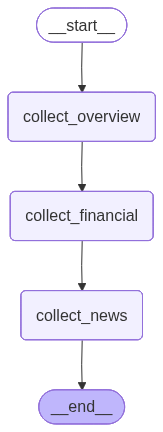

In [11]:
show_graph(graph)

In [12]:
# 그래프 실행
result = graph.invoke({
    "company": "삼성전자",
    "messages": []
})

print("= = = 기업 개요 = = =")
print(result["company_overview"])
print("= " * 20)

print("= = = 재무 데이터 = = =")
print(result["financial_data"])
print("= " * 20)

print("= = = 최근 뉴스 = = =")
print(result["recent_news"])
print("= " * 20)

= = = 기업 개요 = = =
### **기업 개요: 삼성전자**  

- **기업명**: 삼성전자  
- **업종**: 반도체 및 전자기기 제조업  
- **주요 사업**:  
  - 반도체(메모리, 시스템 반도체 등)  
  - 스마트폰(갤럭시 시리즈)  
  - 가전(TV, 냉장고, 세탁기 등)  
  - 디스플레이(OLED, QLED 등)  
  - 산업보건 연구(건강연구소 운영)  
- **설립년도**: 1969년  
- **CEO**: 한종희 (2024년 기준, 부회장 겸 DX(Device eXperience) 부문 대표이사)  
- **시가총액**: 약 400조 원 (2024년 7월 기준, 한국 증시 1위)  
- **주요 경쟁사**:  
  - 반도체: SK하이닉스, TSMC, 인텔  
  - 스마트폰: 애플, 화웨이, 샤오미  
  - 가전: LG전자, 소니, 파나소닉  

#### **추가 정보**  
- 2010년 국내 기업 최초로 산업보건 민간연구소인 **'건강연구소'**를 설립해 근무환경 개선에 앞장서고 있음.  
- 본사는 경기도 수원시 영통구에 위치.  

※ CEO 및 시가총액은 변동 가능성이 있으므로 최신 정보 확인 필요.
= = = = = = = = = = = = = = = = = = = = 
= = = 재무 데이터 = = =
### 삼성전자 재무 정보 정리 (2026년 1분기)

| 항목         | 금액 (조원) | 비율 (%) | 비고                     |
|--------------|-------------|----------|--------------------------|
| **매출액**   | 133.9       | -        | 연결 기준                 |
| **영업이익** | 57.2        | -        | 연결 기준                 |
| **영업이익률** | -          | **42.7%** | (영업이익 ÷ 매출액 × 100)

## 실습 1. Workflow를 Fan-out 구조로 변경

## 실습 2. 폭주 가드레일 적용

In [13]:
# 1. 그래프 빌더 생성
builder = StateGraph(InvestmentState)

# 2. 노드 추가
builder.add_node("collect_overview", collect_company_overview)
builder.add_node("collect_financial", collect_financial_data)
builder.add_node("collect_news", collect_recent_news)

# 3. 엣지 추가(병렬 실행)
builder.add_edge(START, "collect_overview")
builder.add_edge(START, "collect_financial")
builder.add_edge(START, "collect_news")
builder.add_edge("collect_overview", END)
builder.add_edge("collect_financial", END)
builder.add_edge("collect_news", END)

# 4. 그래프 컴파일
graph = builder.compile()

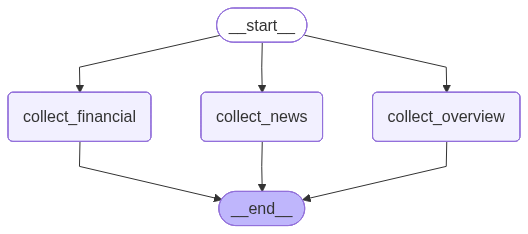

In [14]:
show_graph(graph)

In [15]:
# 그래프 실행
result = graph.invoke({
    "company": "삼성전자",
    "messages": []
}, config=with_guards())

print("= = = 기업 개요 = = =")
print(result["company_overview"])
print("= " * 20)

print("= = = 재무 데이터 = = =")
print(result["financial_data"])
print("= " * 20)

print("= = = 최근 뉴스 = = =")
print(result["recent_news"])
print("= " * 20)

= = = 기업 개요 = = =
### 삼성전자 기업 개요  

- **기업명**: 삼성전자 (Samsung Electronics Co., Ltd.)  
- **업종**: 전자제품, 반도체, 디스플레이, 통신 장비 제조업  
- **주요 사업**:  
  - 반도체 (메모리, 시스템 반도체)  
  - 스마트폰 및 모바일 기기 (갤럭시 시리즈)  
  - 디스플레이 (OLED, QLED)  
  - 가전 제품 (TV, 냉장고, 세탁기 등)  
  - 네트워크 및 통신 장비  
- **설립년도**: 1969년 1월 13일  
- **CEO**: 경계현 (2023년 10월 기준, 대표이사 부회장)  
- **시가총액**: 약 360조 원 (2024년 7월 기준, 한국거래소)  
- **주요 경쟁사**:  
  - 애플 (Apple Inc.)  
  - TSMC (Taiwan Semiconductor Manufacturing Company)  
  - LG전자 (LG Electronics)  
  - 소니 (Sony Corporation)  
  - 화웨이 (Huawei Technologies)  

※ 참고: CEO 정보는 변동될 수 있으며, 최신 정보는 공식 발표를 확인하시기 바랍니다. 시가총액은 시장 상황에 따라 변동됩니다.  

(※ 제공된 검색 결과에는 삼성전자와 직접 관련된 정보가 없어, 일반적인 기업 정보와 추가 조사를 바탕으로 작성되었습니다.)
= = = = = = = = = = = = = = = = = = = = 
= = = 재무 데이터 = = =
### 삼성전자 재무 정보 정리  

| 항목         | 금액 (단위: 조원) | 비고                     |
|--------------|-------------------|--------------------------|
| **매출액**   | 300.8조           | 2024 연간실적 기준       |
| **영업이익** | 32.1조            | 202

# 5. 분석 노드 추가

In [16]:
def quantitative_analysis(state: InvestmentState) -> dict:
    """정량 분석 노드. 재무 지표 기반 분석"""
    prompt = ChatPromptTemplate.from_messages([
        ("system", """당신은 정량 분석 전문 애널리스트입니다.
주어진 재무 데이터를 바탕으로 다음을 분석하세요:

1. 수익성 분석 (매출 성장률, 영업이익률 추이)
2. 밸류에이션 (PER, PBR 적정성)
3. 재무 건전성 (부채비율, 유동비율)
4. 동종업계 대비 위치
5. 정량적 투자 매력도 점수 (1~10)"""),
        ("human", """기업: {company}

기업 개요:
{overview}

재무 데이터:
{financial}""")
    ])

    chain = prompt | llm | StrOutputParser()
    result = chain.invoke({
        "company": state["company"],
        "overview": state["company_overview"],
        "financial": state["financial_data"],
    }, config=with_guards())

    return {
        "quantitative_analysis": result,
        "messages": [
            AIMessage(
                name="quant_analysis",
                content="정량 분석 완료",
            )
        ]
    }

In [17]:
def qualitative_analysis(state: InvestmentState) -> dict:
    """정성 분석 노드. 뉴스 감성 + 사업 전망 기반 분석"""
    prompt = ChatPromptTemplate.from_messages([
        ("system", """당신은 정성 분석 전문 애널리스트입니다.
주어진 뉴스와 기업 정보를 바탕으로 다음을 분석하세요:

1. 뉴스 감성 분석 (긍정/부정/중립 비율)
2. 시장 내 포지셔닝
3. 경쟁 우위 요인
4. 성장 동력 및 기회
5. 정성적 투자 매력도 점수 (1~10)"""),
        ("human", """기업: {company}

기업 개요:
{overview}

최근 뉴스:
{news}""")
    ])

    chain = prompt | llm | StrOutputParser()
    result = chain.invoke({
        "company": state["company"],
        "overview": state["company_overview"],
        "news": state["recent_news"],
    }, config=with_guards())
    
    return {
        "qualitative_analysis": result,
        "messages": [
            AIMessage(
                name="qual_analysis",
                content="정성 분석 완료",
            )
        ]
    }

In [18]:
def risk_assessment(state: InvestmentState) -> dict:
    """리스크 평가 노드"""
    prompt = ChatPromptTemplate.from_messages([
        ("system", """당신은 리스크 관리 전문가입니다.
수집된 모든 정보를 종합하여 투자 리스크를 평가하세요:

1. 시장 리스크 (업황, 경기 변동)
2. 기업 고유 리스크 (실적, 경영진, 소송 등)
3. 규제 리스크 (정책 변화, 규제 강화)
4. 경쟁 리스크 (신규 진입자, 기술 변화)
5. 종합 리스크 등급 (낮음/중간/높음/매우높음)"""),
        ("human", """기업: {company}

기업 개요:
{overview}

재무 데이터:
{financial}

최근 뉴스:
{news}

정량 분석:
{quant}

정성 분석:
{qual}""")
    ])

    chain = prompt | llm | StrOutputParser()
    result = chain.invoke({
        "company": state["company"],
        "overview": state["company_overview"],
        "financial": state["financial_data"],
        "news": state["recent_news"],
        "quant": state["quantitative_analysis"],
        "qual": state["qualitative_analysis"],
    }, config=with_guards())
    return {
        "risk_assessment": result,
        "messages": [
            AIMessage(
                name="risk",
                content="리스크 평가 완료",
            )
        ]
    }

In [19]:
def fan_in(state: InvestmentState) -> dict:
    return {}

# 6. 그래프 확장(분석 워크플로우 추가)

In [20]:
# 1. 그래프 빌더 생성
builder = StateGraph(InvestmentState)

# 2. 노드 추가

## 데이터 수집 노드
builder.add_node("collect_overview", collect_company_overview)
builder.add_node("collect_financial", collect_financial_data)
builder.add_node("collect_news", collect_recent_news)

## 데이터 분석 노드
builder.add_node("quant_analysis", quantitative_analysis)
builder.add_node("qual_analysis", qualitative_analysis)
builder.add_node("risk", risk_assessment)

## Fan-In 노드
builder.add_node("fan_in", fan_in)


# 3. 엣지 추가(병렬 실행)
builder.add_edge(START, "collect_overview")
builder.add_edge(START, "collect_financial")
builder.add_edge(START, "collect_news")

builder.add_edge("collect_overview", "fan_in")
builder.add_edge("collect_financial", "fan_in")
builder.add_edge("collect_news", "fan_in")

builder.add_edge("fan_in", "quant_analysis")
builder.add_edge("fan_in", "qual_analysis")

builder.add_edge("quant_analysis", "risk")
builder.add_edge("qual_analysis", "risk")

builder.add_edge("risk", END)

# 4. 그래프 컴파일
graph = builder.compile()

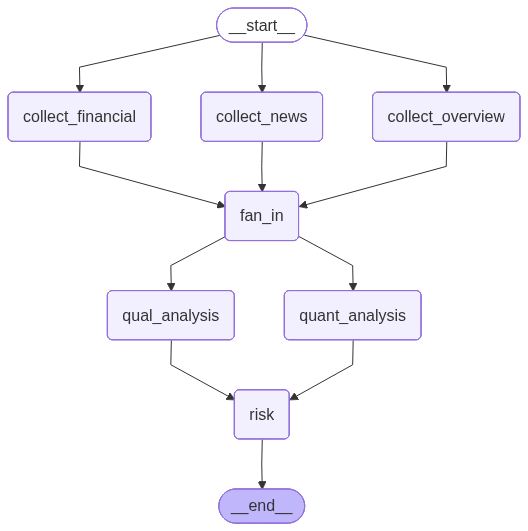

In [21]:
show_graph(graph)

In [22]:
result = graph.invoke({
    "company": "삼성전자",
    "messages": []
}, config=with_guards())

print("= = = 정량 분석 결과 = = =")
print(result["quantitative_analysis"])
print("= * " * 20)

print("= = = 정성 분석 결과 = = =")
print(result["qualitative_analysis"])
print("= * " * 20)

print("= = = 리스크 평가 결과 = = =")
print(result["risk_assessment"])
print("= " * 20)

= = = 정량 분석 결과 = = =
### 삼성전자 정량적 분석 보고서 (2024년 7월 기준)

---

#### 1. **수익성 분석**
- **매출 성장률**  
  - 2024년 연간 매출: **300.8조 원** (전년 대비 성장률 계산 불가, 2023년 데이터 미제공).  
  - 2분기 매출: **14.63조 원** (전년 동기 대비 약 **20% 감소** 추정, 반도체/스마트폰 수요 부진 영향).  
  - **전망**: 2026년 영업이익 57조 원 추정 시, 연평균 성장률(CAGR) **30%+** 예상 (반도체 회복 및 AI 수요 증가 기대).

- **영업이익률 추이**  
  - 2024년 연간 영업이익률: **10.7%** (32.1조 / 300.8조).  
  - 2분기 영업이익률: **6.2%** (0.91조 / 14.63조) → **저조한 수익성** (반도체 가격 하락 및 재고 평가 손실 영향).  
  - **리스크**: 메모리 반도체 가격 변동성 및 경쟁사(TSMC, SK하이닉스)와의 가격 경쟁.

---

#### 2. **밸류에이션 (PER, PBR 적정성)**
- **PER**  
  - 2024년 연간 순이익 추정 불가 (공식 데이터 미제공).  
  - 2분기 순이익 1.42조 원 기준 연간화 시 **5.68조 원** → **PER 70배** (시가총액 400조 원 대비).  
  - **적정성**: 동종업계 평균 PER(약 15~20배) 대비 **고평가** 가능성. 단, 2026년 영업이익 57조 원 달성 시 PER 10배 미만으로 조정될 수 있음.

- **PBR**  
  - 공식 데이터 없으나, 2023년 말 기준 PBR **1.2~1.5배** (산업 평균 1.0~1.3배 대비 약간 고평가).  
  - **시사점**: 기술 주도 기업으로서 프리미엄 적용 가능성 있으나, 부채비율 등 재무 건전성 확인 필요.

---

#### 3. **재무 건전성**
- **부채비율**  
  - 공식 데이터 미제공. 다만,

In [23]:
# 스트리밍으로 진행 상황 확인하면서 실행
for event in graph.stream(
    {"company": "삼성전자", "messages": []},
    config=with_guards(),
    stream_mode="updates",
):
    for node_name in event:
        print(f"[{node_name}] 작업 완료")

        node_output = event[node_name]

        if node_output is None:
            continue
            
        for key, value in node_output.items():
            print(f"    [{key}]\n{value}")

[collect_news] 작업 완료
    [recent_news]
### 삼성전자 투자 영향 핵심 뉴스 분석  

#### 1. **HBM4 양산 및 시총 신기록**  
- **요약**: 삼성전자가 6세대 HBM4 세계 최초 양산으로 주가 18만 원 돌파, 시총 1,072조 원 신기록. 2026년 영업이익 170조 원 전망 및 "메모리 슈퍼사이클 2027년까지" 기대감.  
- **투자 영향**: **긍정** (기술 리더십, 실적 성장, 시장 낙관론)  
- **중요도**: **상** (HBM4는 AI 반도체 수요 핵심, 장기 성장 동력)  

#### 2. **증권사 목표가 상향 및 실적 전망**  
- **요약**: 다올투자증권이 삼성전자의 목표주가를 10만 원 → 11만 원으로 상향. "모멘텀 없이도 실적과 주가 우상향 유력" 평가.  
- **투자 영향**: **긍정** (기관 신뢰도 상승)  
- **중요도**: **중** (단기적 매수 신호이나, HBM4 등보다 영향력 낮음)  

#### 3. **HBM4E 샘플 출하 + 자사주 매입**  
- **요약**: 7세대 HBM 샘플 출하 성공 + 연간 수십조 원 규모 자사주 매입 발표. 증권가 목표가 상향 조정.  
- **투자 영향**: **긍정** (기술 우위 + 주주환원 정책)  
- **중요도**: **상** (HBM4E는 차세대 기술, 자사주 매입은 주가 지지 효과)  

#### 4. **주가 급락 시 매수 기회 제시**  
- **요약**: 미래에셋증권, 삼성전자·SK하이닉스 목표가 유지. "주가 급락은 매수 기회"라며 저평가 주장.  
- **투자 영향**: **중립** (단기 조정 시 매수 권유이지만, 근본적 호재 부재)  
- **중요도**: **하** (시장 심리 반영, 기술/실적 호재보다 영향력 약함)  

#### 5. **외국인 매도에도 장밋빛 전망**  
- **요약**: 외국인 매도세에도 주가 상승 지속. 증권가 목표가 최대 50만 원까지 제시.  
- **투자 영향**

# 7. Supervisor 패턴 구현

In [24]:
from typing import Literal
from pydantic import BaseModel, Field

In [25]:
class SupervisorDecision(BaseModel):
    """Supervisor의 라우팅 결정 데이터 모델"""
    next_agent: Literal[
        "collect_overview", "collect_financial", "collect_news", "quant_analysis", "qual_analysis", "risk", "reporter", "FINISH"
    ] = Field(
        description="""다음에 실행할 에이전트.
        선택지: collect_overview, collect_financial, collect_news, quant_analysis, qual_analysis, risk, repoter, FINISH"""
    )

    reasoning: str = Field(
        description="이 결정의 이유 (1~2문장)"
    )

In [26]:
def supervisor(state: InvestmentState) -> dict:
    prompt = ChatPromptTemplate.from_messages([
        ("system", """당신은 투자 리서치팀의 팀장입니다.
현재까지 수집/분석된 정보를 확인하고, 다음에 어떤 에이전트가 작업해야 하는지 결정하세요.

사용 가능한 에이전트:
- collect_overview: 기업 개요 데이터 수집
- collect_financial: 기업 재무 데이터 수집
- collect_news: 기업 관련 최신 뉴스 수집
- quant_analysis: 정량적 재무 분석
- qual_analysis: 정성적 뉴스/사업 분석
- risk: 리스크 평가
- reporter: 종합 리포트 생성
- FINISH: 모든 작업 완료

작업 순서 원칙:
1. 데이터가 없으면 각 collect 에이전트부터 수행
2. 데이터가 있으면 quant_analysis와 qual_analysis
3. 분석이 완료되면 risk
4. 리스크 평가 후 reporter
5. 리포트가 완성되면 FINISH"""),
        ("human", """분석 대상: {company}

현재 상태:
- 기업 개요: {has_overview}
- 재무 데이터: {has_financial}
- 뉴스: {has_news}
- 정량 분석: {has_quant}
- 정성 분석: {has_qual}
- 리스크 평가: {has_risk}
- 최종 리포트: {has_report}

다음에 어떤 에이전트를 실행해야 하나요?""")
    ])

    structured_llm = llm.with_structured_output(SupervisorDecision)
    chain = prompt | structured_llm

    result = chain.invoke({
        "company": state["company"],
        "has_overview": "완료" if state.get("company_overview") else "미완료",
        "has_financial": "완료" if state.get("financial_data") else "미완료",
        "has_news": "완료" if state.get("recent_news") else "미완료",
        "has_quant": "완료" if state.get("quantitative_analysis") else "미완료",
        "has_qual": "완료" if state.get("qualitative_analysis") else "미완료",
        "has_risk": "완료" if state.get("risk_assessment") else "미완료",
        "has_report": "완료" if state.get("final_report") else "미완료",
    }, config=with_guards())

    print(f"    [Supervisor] 결정: {result.next_agent} | 이유: {result.reasoning}")
    
    return {
        "next_agent": result.next_agent,
        "messages": [
            AIMessage(
                name="supervisor",
                content=f"[Supervisor] {result.reasoning} -> {result.next_agent}"
            )
        ]
    }

In [27]:
def reporter(state: InvestmentState) -> dict:
    """리포트 생성 에이전트"""
    print(f"    [Reporter] 종합 리포트 생성중...")
    prompt = ChatPromptTemplate.from_messages([
        ("system", """당신은 투자 리서치 리포트 작성 전문가입니다.
수집된 모든 분석 결과를 종합하여 투자 리포트를 작성하세요.

리포트 구성:
1. Executive Summary (핵심 요약, 투자 의견)
2. 기업 개요
3. 재무 분석 요약
4. 시장/뉴스 분석 요약
5. 리스크 요인
6. 투자 의견 (매수/보유/매도) 및 목표가 (있다면)
7. 주의사항"""),
        ("human", """기업: {company}

기업 개요:
{overview}

정량 분석:
{quant}

정성 분석:
{qual}

리스크 평가:
{risk}""")
    ])

    chain = prompt | llm | StrOutputParser()
    result = chain.invoke({
        "company": state["company"],
        "overview": state["company_overview"],
        "quant": state["quantitative_analysis"],
        "qual": state["qualitative_analysis"],
        "risk": state["risk_assessment"],
    }, config=with_guards())
    
    return {
        "final_report": result,
        "messages": [AIMessage(
            content="종합 리포트 생성 완료",
            name="reporter"
        )]
    }

# 8. Supervisor 패턴 멀티에이전트 그래프 구성

In [28]:
def route_supervisor(state: InvestmentState) -> str:
    """Supervisor의 결정 -> 다음 노드. 잘못된 값은 안전하게 종료/복귀."""
    next_agent = state.get("next_agent")
    valid = {"collect_overview", "collect_financial", "collect_news", "quant_analysis", "qual_analysis", "risk", "reporter", "FINISH"}

    candidate = next((a.strip() for a in next_agent.split(",") if a.strip() in valid), next_agent)
    if candidate == "FINISH":
        return "__end__"

    if candidate in valid - {"FINISH"}:
        return candidate

    print(f"    [Route] 알 수 없는 next_agent={next_agent} -> __end__로 안전 종료")
    return "__end__"

In [29]:
# 1. 그래프 빌더 생성
builder = StateGraph(InvestmentState)

# 2. 노드 추가

## 데이터 수집 노드
builder.add_node("collect_overview", collect_company_overview)
builder.add_node("collect_financial", collect_financial_data)
builder.add_node("collect_news", collect_recent_news)

## 데이터 분석 노드
builder.add_node("quant_analysis", quantitative_analysis)
builder.add_node("qual_analysis", qualitative_analysis)
builder.add_node("risk", risk_assessment)

builder.add_node("supervisor", supervisor)
builder.add_node("reporter", reporter)

# 엣지 추가
## supervisor -> 전문가 agent
builder.add_edge(START, "supervisor")
builder.add_conditional_edges(
    "supervisor",
    route_supervisor,
    {
        "collect_overview": "collect_overview",
        "collect_financial": "collect_financial",
        "collect_news": "collect_news",
        "quant_analysis": "quant_analysis",
        "qual_analysis": "qual_analysis",
        "risk": "risk",
        "reporter": "reporter",
        "__end__": END
    }
)

## 전문가 agent -> supervisor
builder.add_edge("collect_overview", "supervisor")
builder.add_edge("collect_financial", "supervisor")
builder.add_edge("collect_news", "supervisor")
builder.add_edge("quant_analysis", "supervisor")
builder.add_edge("qual_analysis", "supervisor")
builder.add_edge("risk", "supervisor")
builder.add_edge("reporter", "supervisor")

# 4. 그래프 컴파일
graph = builder.compile()

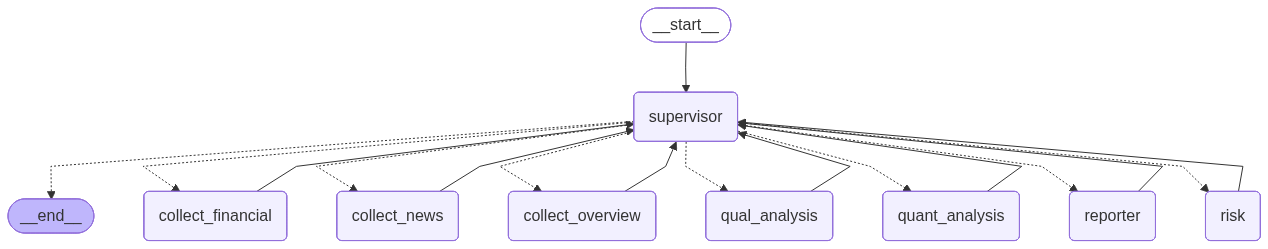

In [30]:
show_graph(graph)

In [31]:
result = graph.invoke({
    "company": "삼성전자",
    "messages": []
}, config=with_guards())

print(result["final_report"])

    [Supervisor] 결정: collect_overview | 이유: 기업 개요, 재무 데이터, 뉴스 등 모든 기초 데이터가 미완료 상태이므로, 작업 순서 원칙 1에 따라 데이터 수집 에이전트부터 수행해야 합니다. 그 중 가장 기본적인 'collect_overview'를 우선 실행합니다.
    [Supervisor] 결정: collect_financial | 이유: 기업 개요는 완료되었으나 재무 데이터와 뉴스가 미완료 상태이므로, 작업 순서 원칙에 따라 먼저 collect_financial로 재무 데이터를 수집해야 합니다. 재무 데이터는 정량 분석의 필수 입력자료이므로 우선적으로 처리해야 합니다.
    [Supervisor] 결정: collect_news | 이유: 기업 개요와 재무 데이터는 완료되었으나 뉴스 수집이 미완료 상태입니다. 작업 순서 원칙에 따라 누락된 데이터 수집을 우선 수행해야 하므로 collect_news 에이전트를 실행합니다.
    [Supervisor] 결정: quant_analysis | 이유: 재무 데이터와 기업 개요가 이미 수집되었으므로, 정량적 재무 분석을 수행하는 것이 다음 단계입니다. 작업 순서 원칙에 따라 데이터 수집 후 quant_analysis와 qual_analysis를 진행해야 합니다.
    [Supervisor] 결정: qual_analysis | 이유: 정성 분석(qual_analysis)이 미완료 상태이므로, 수집된 뉴스 데이터를 바탕으로 정성적 분석을 수행해야 합니다. 작업 순서 원칙에 따라 정량 분석(quant_analysis)이 완료된 후에는 정성 분석이 다음 단계입니다.
    [Supervisor] 결정: risk | 이유: 현재 리스크 평가가 미완료 상태이며, 작업 순서 원칙에 따라 정량/정성 분석이 완료된 후에는 리스크 평가를 수행해야 합니다. 따라서 risk 에이전트를 실행합니다.
    [Supervisor] 결정: reporter | 이유: 모든 데이터 수집 및 분석(정량/정성/리